In [1]:
from datasets import load_dataset, load_from_disk
from typing import List, Tuple, Union, List
from collections import Counter
import gc
import json
import gc
import pandas as pd

BASE_PATH = "../../data/qa_datasets/"
DATASET_DIR_NAME = "2wikimultihopqa_dev"

SAVE_DATASET_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/original"
SAVE_TMP_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/tmp_2wikimultihopqa_cntx.csv" 
SAVE_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/relevant_contexts.csv"
SAVE_QA_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/qa_pairs.csv"
SAVE_STATS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/stats.json"

DOC_MAX_LEN = 1024
DOC_MIN_LEN = 64
MAX_QA_PAIRS = 2000
NOISE_DOCUMENTS_AMOUNT = 0

/home/dzigen/Desktop/Projects/PersonalAI/.pai_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import preprocess_documents, plot_textlen_distribution, \
    preprocess_qapairs, select_noise_documents, calculate_dataset_stats, \
        check_dataset_consistency, calculate_original_dataset_stats

In [3]:
with open(f"{SAVE_DATASET_PATH}/dev.json", 'r', encoding='utf-8') as fd:
    original_dataset = json.load(fd)

In [4]:
Counter([item['type']for item in original_dataset])

Counter({'compositional': 5236,
         'comparison': 3040,
         'bridge_comparison': 2751,
         'inference': 1549})

In [5]:
original_dataset[0]

{'_id': '8813f87c0bdd11eba7f7acde48001122',
 'type': 'compositional',
 'question': 'Who is the mother of the director of film Polish-Russian War (Film)?',
 'context': [['Maheen Khan',
   ['Maheen Khan is a Pakistani fashion and costume designer, also an award winner fashion designer for fashion labels like" The Embroidery HouseMaheen" and" Gulabo".',
    'She has done many national and international fashion events and shows.',
    'She undertook embroidery for the film Snow White and the Huntsman and television series',
    'The Jewel in the Crown.']],
  ['Viktor Yeliseyev',
   ['Viktor Petrovich Yeliseyev( born June 9, 1950) is a Russian general, orchestra conductor and music teacher.',
    'He is the director of the Ministry of the Interior Ensemble, one of the two Russian Red Army Choirs.']],
  ['Alice Washburn',
   ['Alice Washburn( 1860- 1929) was an American stage and film actress.',
    'She worked at the Edison, Vitagraph and Kalem studios.',
    'Her final film Snow White was 

In [6]:
def get_question_documents(dataset: object, idx: int) -> List[Tuple[Union[None,str], str]]: 
    documents = []
    for document in dataset[idx]['context']:
        title, text = document[0], ' '.join(document[1])
        documents.append((title, text))
    return documents

def get_dataset_len(dataset: object) -> int:
    return len(dataset)

def get_qa_info(dataset: object, idx: int) -> Tuple[str, str, str, List[Tuple[Union[None, str], str]]]:
    question, question_type, answer = dataset[idx]['question'], dataset[idx]['type'], dataset[idx]['answer']

    relevant_titles = set(map(lambda item: item[0], dataset[idx]['supporting_facts']))
    relevant_documents = []
    for document in dataset[idx]['context']:
        title, text = document[0], ' '.join(document[1])
        if title in relevant_titles:
            relevant_documents.append((title, text))

    return question, question_type, answer, relevant_documents

In [7]:
CUSTOM_FUNCS = {
    'get_question_documents': get_question_documents,
    'get_dataset_len': get_dataset_len,
    'get_qa_info': get_qa_info
}

In [18]:
question, _, answer, relevant_documents = CUSTOM_FUNCS['get_qa_info'](original_dataset, 0)

In [8]:
calculate_original_dataset_stats(original_dataset, CUSTOM_FUNCS)

  0%|          | 0/12576 [00:00<?, ?it/s]

100%|██████████| 12576/12576 [00:00<00:00, 91583.91it/s]


Questions (with duplications):
{'median': 67.0, 'mean': 68.38915, 'std': 17.42157, 'min': 23, 'max': 179, 'count': 12576}
Questions (w/o duplications):
{'median': 67.0, 'mean': 68.38915, 'std': 17.42157, 'min': 23, 'max': 179, 'count': 12576}
Answers (with duplications):
{'median': 13.0, 'mean': 14.27576, 'std': 9.19334, 'min': 2, 'max': 79, 'count': 12576}
Answers (w/o duplications):
{'median': 15.0, 'mean': 16.90454, 'std': 8.63745, 'min': 2, 'max': 79, 'count': 8171}
Documents (with duplications):  125760
Documents (w/o duplications):  56687
Documents per questions: 
{'median': 2.0, 'mean': 2.4375, 'std': 0.8268, 'min': 2, 'max': 4, 'count': 12576}


### Preprocessing documents

In [8]:
accepted_documents_df = preprocess_documents(
    original_dataset, DOC_MIN_LEN, DOC_MAX_LEN, CUSTOM_FUNCS)

100%|██████████| 12576/12576 [00:00<00:00, 43341.65it/s]


In [ ]:
accepted_documents_df.to_csv(SAVE_TMP_CONTEXTS_PATH, index=False)

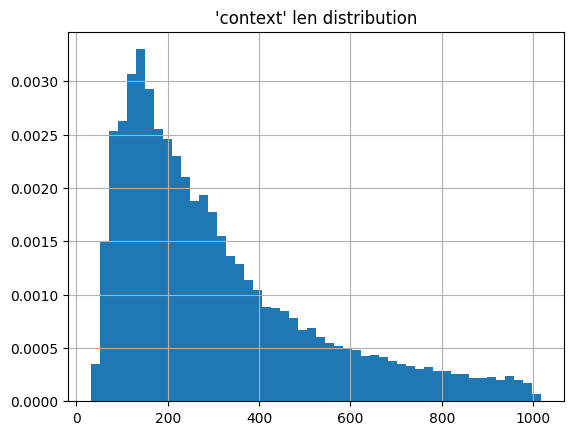

In [9]:
plot_textlen_distribution(accepted_documents_df, 'context')

In [10]:
accepted_documents_df.head()

,title,context,hash,original_qaidx
0,Maheen Khan,Maheen Khan is a Pakistani fashion and costume...,e7916143fb9f87502444e467b35a7d22,0
1,Viktor Yeliseyev,"Viktor Petrovich Yeliseyev( born June 9, 1950)...",30241fc259d08319bb5f803556ac203a,0
2,Alice Washburn,Alice Washburn( 1860- 1929) was an American st...,4230ddb570ecff648f5c04b313157543,0
3,Polish-Russian War (film),Polish-Russian War (Wojna polsko-ruska) is a 2...,a23632c49331d3e7158a339adb16fdff,0
4,A Snow White Christmas,A Snow White Christmas is a Christmas animated...,d8897cd98bc7fa988c180cd4dddee25e,0


In [11]:
accepted_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49299 entries, 0 to 49298
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           49299 non-null  object
 1   context         49299 non-null  object
 2   hash            49299 non-null  object
 3   original_qaidx  49299 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [11]:
accepted_documents_df.shape

(49299, 4)

In [16]:
len(set(accepted_documents_df['context'].tolist()))

49293

### Preprocessing QA pairs

In [13]:
qapairs_df, relevant_documents_df = preprocess_qapairs(
    original_dataset, accepted_documents_df, MAX_QA_PAIRS, CUSTOM_FUNCS)

 24%|██▍       | 3063/12576 [00:00<00:00, 55564.15it/s]


In [ ]:
qapairs_df.to_csv(SAVE_QA_PATH, index=False)

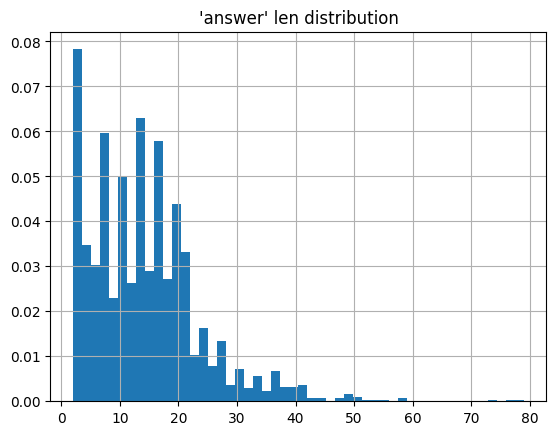

In [14]:
plot_textlen_distribution(qapairs_df, 'answer')

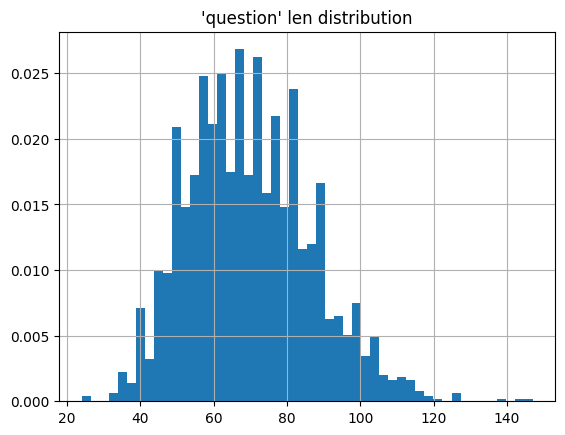

In [15]:
plot_textlen_distribution(qapairs_df, 'question')

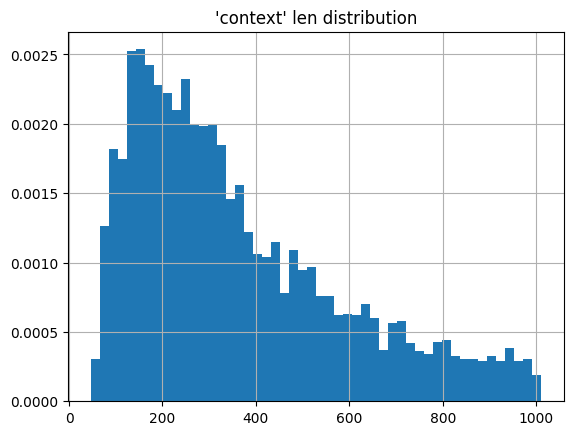

In [16]:
plot_textlen_distribution(relevant_documents_df, 'context')

In [17]:
qapairs_df

,question,type,answer,cntx_ids,qa_idx,original_qaidx
0,Who is the mother of the director of film Poli...,compositional,Małgorzata Braunek,"[0, 1]",0,0
1,"Which film came out first, Blind Shaft or The ...",comparison,The Mask Of Fu Manchu,"[2, 3]",1,1
2,"When did John V, Prince Of Anhalt-Zerbst's fat...",compositional,12 June 1516,"[4, 5]",2,2
3,What is the award that the director of film We...,compositional,Myanmar Motion Picture Academy Awards,"[6, 7]",3,3
4,Who is Charles Bretagne Marie De La Trémoille'...,inference,Charles Armand René de La Trémoille,"[8, 9]",4,5
...,...,...,...,...,...,...
1995,Are Fisher Communications and Empire Kosher bo...,comparison,yes,"[4586, 4587]",1995,3056
1996,When was the company that published National I...,compositional,1985,"[4588, 4589]",1996,3057
1997,Which country Shah Muhammad (Kara Koyunlu)'s f...,compositional,Black sheep Turkomans,"[4590, 4591]",1997,3059
1998,Are Quaqtaq Airport and Fort Nelson/Gordon Fie...,comparison,yes,"[4592, 4593]",1998,3060


In [18]:
qapairs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question        2000 non-null   object
 1   type            2000 non-null   object
 2   answer          2000 non-null   object
 3   cntx_ids        2000 non-null   object
 4   qa_idx          2000 non-null   int64 
 5   original_qaidx  2000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 93.9+ KB


In [19]:
qapairs_df.shape

(2000, 6)

In [20]:
relevant_documents_df

,title,context,cntx_idx,hash
0,Polish-Russian War (film),Polish-Russian War (Wojna polsko-ruska) is a 2...,0,a23632c49331d3e7158a339adb16fdff
1,Xawery Żuławski,Xawery Żuławski (born 22 December 1971 in Wars...,1,03e78a2115c7401abe1985ca88ddc58e
2,Blind Shaft,Blind Shaft is a 2003 film about a pair of bru...,2,5f81eca1a49862947f6076fa910f5593
3,The Mask of Fu Manchu,The Mask of Fu Manchu is a 1932 pre-Code adven...,3,fbfd94b02d71d66981158e9de0e4a675
4,"John V, Prince of Anhalt-Zerbst","John V of Anhalt-Zerbst (Dessau, 4 September 1...",4,e046c19181bb7924533d964b34f72114
...,...,...,...,...
4591,Shah Muhammad (Kara Koyunlu),Shah Muhammad (died 5 August 1433) was a son o...,4591,1cfc9cd51b2edf219e29bdd37101125f
4592,Quaqtaq Airport,"Quaqtaq Airport,, is located near Quaqtaq, Que...",4592,905b89c5916307af7b7265dc05f145af
4593,Fort Nelson/Gordon Field Airport,"Fort Nelson/ Gordon Field Airport,, is located...",4593,aeb2af54dbdfee6a84480d0a7e3fbb7a
4594,Grand General (band),Grand General( initiated 2010 in Trondheim as ...,4594,6dc3238381c1e01b77be07bed80aba28


In [21]:
relevant_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     4596 non-null   object
 1   context   4596 non-null   object
 2   cntx_idx  4596 non-null   int64 
 3   hash      4596 non-null   object
dtypes: int64(1), object(3)
memory usage: 143.8+ KB


In [22]:
relevant_documents_df.shape

(4596, 4)

### Expanding relevant documents dataframe by noise documents

In [23]:
DOCIDX_OFFSET = max(relevant_documents_df['cntx_idx'].tolist()) + 1
print(DOCIDX_OFFSET)
noise_documents_df = select_noise_documents(
    relevant_documents_df, accepted_documents_df, 
    NOISE_DOCUMENTS_AMOUNT, DOCIDX_OFFSET, CUSTOM_FUNCS)

expanded_relevant_documents_df = pd.concat([relevant_documents_df, noise_documents_df], ignore_index=True)

4596


0it [00:00, ?it/s]


In [ ]:
expanded_relevant_documents_df.to_csv(SAVE_CONTEXTS_PATH, index=False)

In [24]:
noise_documents_df

,title,context,cntx_idx,hash


In [25]:
noise_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     0 non-null      object
 1   context   0 non-null      object
 2   cntx_idx  0 non-null      object
 3   hash      0 non-null      object
dtypes: object(4)
memory usage: 124.0+ bytes


In [26]:
noise_documents_df.shape

(0, 4)

/home/dzigen/Desktop/Projects/PersonalAI/.pai_venv/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


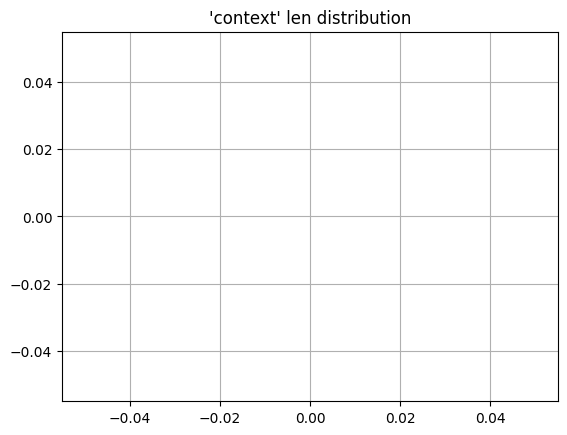

In [27]:
plot_textlen_distribution(noise_documents_df, 'context')

In [28]:
expanded_relevant_documents_df

,title,context,cntx_idx,hash
0,Polish-Russian War (film),Polish-Russian War (Wojna polsko-ruska) is a 2...,0,a23632c49331d3e7158a339adb16fdff
1,Xawery Żuławski,Xawery Żuławski (born 22 December 1971 in Wars...,1,03e78a2115c7401abe1985ca88ddc58e
2,Blind Shaft,Blind Shaft is a 2003 film about a pair of bru...,2,5f81eca1a49862947f6076fa910f5593
3,The Mask of Fu Manchu,The Mask of Fu Manchu is a 1932 pre-Code adven...,3,fbfd94b02d71d66981158e9de0e4a675
4,"John V, Prince of Anhalt-Zerbst","John V of Anhalt-Zerbst (Dessau, 4 September 1...",4,e046c19181bb7924533d964b34f72114
...,...,...,...,...
4591,Shah Muhammad (Kara Koyunlu),Shah Muhammad (died 5 August 1433) was a son o...,4591,1cfc9cd51b2edf219e29bdd37101125f
4592,Quaqtaq Airport,"Quaqtaq Airport,, is located near Quaqtaq, Que...",4592,905b89c5916307af7b7265dc05f145af
4593,Fort Nelson/Gordon Field Airport,"Fort Nelson/ Gordon Field Airport,, is located...",4593,aeb2af54dbdfee6a84480d0a7e3fbb7a
4594,Grand General (band),Grand General( initiated 2010 in Trondheim as ...,4594,6dc3238381c1e01b77be07bed80aba28


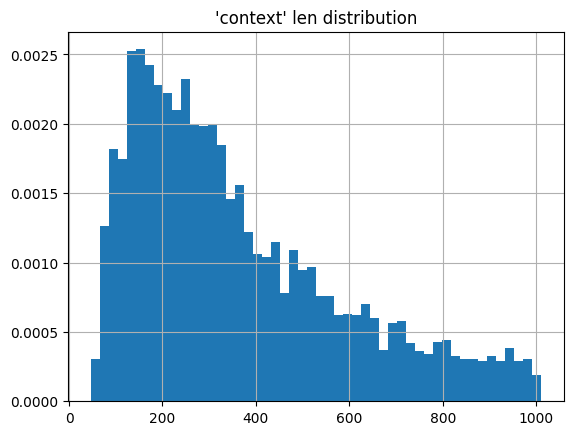

In [29]:
plot_textlen_distribution(expanded_relevant_documents_df, 'context')

### Calculating statistics

In [30]:
processed_dataset_stats = calculate_dataset_stats(qapairs_df, expanded_relevant_documents_df)
processed_dataset_stats['NOISE_DOCUMENTS_AMOUNT'] = NOISE_DOCUMENTS_AMOUNT

In [ ]:
with open(SAVE_STATS_PATH, 'w', encoding='utf-8') as fd:
    json.dump(processed_dataset_stats, fd, indent=1, ensure_ascii=False)

In [31]:
check_dataset_consistency(original_dataset, qapairs_df, expanded_relevant_documents_df, CUSTOM_FUNCS)

100%|██████████| 2000/2000 [00:03<00:00, 644.13it/s]


True

In [32]:
Counter(qapairs_df['type'].tolist())

Counter({'compositional': 716,
         'comparison': 582,
         'bridge_comparison': 491,
         'inference': 211})

In [33]:
processed_dataset_stats

{'contexts_amount': 4596,
 'contexts_len': {'median': 300.0,
  'mean': 362.29809,
  'std': 227.43103,
  'min': 46,
  'max': 1011,
  'count': 4596},
 'qa_pairs_amount': 2000,
 'answers_len': {'median': 13.0,
  'mean': 14.2515,
  'std': 9.41999,
  'min': 2,
  'max': 79,
  'count': 2000},
 'questions_len': {'median': 69.0,
  'mean': 69.805,
  'std': 16.82929,
  'min': 24,
  'max': 147,
  'count': 2000},
 'rel_contexts_per_question': {'median': 2.0,
  'mean': 2.491,
  'std': 0.86077,
  'min': 2,
  'max': 4,
  'count': 2000},
 'NOISE_DOCUMENTS_AMOUNT': 0}